# Task 1: Review Customer Segments

In [7]:
import pandas as pd
df=pd.read_csv("D:\AI-Lab-99\Week 3\week4\Module 7 Cluster Evaluation & Customer Profiling\Final_Customer_Profile_Report.csv")

df.head()


,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Total_Purchase,Total_Campaign,Average Spending per Purchase,Digital_Engagement,Deal_Dependency,Preferred_Shopping_Channel,Product_Preference,Customer_Activity_Level,Cluster,Customer_Segment
0,-0.458383,1.251776,0.299651,0.307039,0.989643,1.470132,1.442724,1.434322,1.455038,1.121518,...,1.380023,0.0,1.176601,1.620481,-0.514589,-2.187642,0.512133,1.276773,0,Premium Loyal Customers
1,-0.458383,1.251776,-0.263808,-0.383664,-1.213866,-1.000697,-1.415023,-0.874095,-0.986677,-0.921817,...,-1.163336,0.0,-1.629866,-0.965311,1.417872,-0.361890,0.512133,-1.211241,1,Digital-First Buyers
2,-0.458383,-0.272125,0.943420,-0.798086,0.768523,1.140985,0.490422,1.383545,0.589966,0.536950,...,0.844579,0.0,0.592428,0.758551,-1.255068,-0.361890,0.512133,1.276773,0,Premium Loyal Customers
3,-0.458383,-0.272125,-1.204881,-0.798086,-1.213866,-0.391042,-0.694700,-0.063762,-0.530925,-1.045693,...,-0.895614,0.0,-1.254015,-0.390691,0.702554,-0.361890,-0.653942,-1.211241,1,Digital-First Buyers
4,1.533425,-0.272125,0.307056,1.550305,0.270284,1.055931,0.442620,0.841975,0.748533,-0.257498,...,0.576857,0.0,0.026695,0.183930,0.818614,-0.361890,0.512133,0.032766,0,Premium Loyal Customers


## Review Customer Segments

In [8]:
print("Unique Customer Segments")

print(df['Cluster'].unique())

print("\nTotal Number of segment :" ,df['Cluster'].nunique())

Unique Customer Segments
[0 1]

Total Number of segment : 2


## Count Customers in Each Segment

In [9]:
segment_count = df["Cluster"].value_counts().sort_index()

print(segment_count)

Cluster
0    1111
1     927
Name: count, dtype: int64


## Calculate Percentage of Customers

In [10]:
segment_percentage = (
    df["Cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

print(segment_percentage)

Cluster
0    54.51
1    45.49
Name: proportion, dtype: float64


## Assign Business Names

In [11]:
cluster_names = {

    0: "Premium Loyal Customers",

    1: "Budget Buyers",

    2: "At-Risk Customers",

    3: "New Customers"

}

df["Business_Name"] = df["Cluster"].map(cluster_names)

df[["Cluster", "Business_Name"]].head()

,Cluster,Business_Name
0,0,Premium Loyal Customers
1,1,Budget Buyers
2,0,Premium Loyal Customers
3,1,Budget Buyers
4,0,Premium Loyal Customers


## Create Customer Segment Summary Table

In [12]:
summary_table = pd.DataFrame({

    "Segment": segment_count.index.map(lambda x: f"Cluster {x}"),

    "Business Name": segment_count.index.map(
        lambda x: cluster_names.get(x, "Unknown")
    ),

    "Customers": segment_count.values,

    "Percentage": segment_percentage.values

})

summary_table

,Segment,Business Name,Customers,Percentage
0,Cluster 0,Premium Loyal Customers,1111,54.51
1,Cluster 1,Budget Buyers,927,45.49


# Task 2: Develop Customer Personas

## Create Base Persona Statistics

In [13]:
persona = df.groupby("Business_Name").agg({

    "Income":"mean",
    "Total_spending":"mean",
    "Total_Purchase":"mean",
    "Recency":"mean",
    "Preferred_Shopping_Channel":lambda x:x.mode()[0],
    "Product_Preference":lambda x:x.mode()[0],
    "Deal_Dependency":"mean",
    "Customer_Activity_Level":lambda x:x.mode()[0],
    "Total_Campaign":"mean"

}).round(2)

persona

,Income,Total_spending,Total_Purchase,Recency,Preferred_Shopping_Channel,Product_Preference,Deal_Dependency,Customer_Activity_Level,Total_Campaign
Business_Name,,,,,,,,,
Budget Buyers,-0.80,-0.97,-0.91,-0.02,-0.36,0.51,0.72,-1.21,0.0
Premium Loyal Customers,0.67,0.81,0.76,0.01,-0.36,0.51,-0.60,1.28,0.0


## Generate Detailed Customer Personas

In [14]:
for segment in persona.index:

    income = persona.loc[segment,"Income"]
    spending = persona.loc[segment,"Total_spending"]
    purchase = persona.loc[segment,"Total_Purchase"]
    recency = persona.loc[segment,"Recency"]
    product = persona.loc[segment,"Product_Preference"]
    channel = persona.loc[segment,"Preferred_Shopping_Channel"]
    campaign = persona.loc[segment,"Total_Campaign"]
    deals = persona.loc[segment,"Deal_Dependency"]
    activity = persona.loc[segment,"Customer_Activity_Level"]

    print("="*70)
    print("Customer Segment :",segment)
    print("="*70)

    # Income
    if income>=70000:
        print("Income Level : High Income")
    elif income>=40000:
        print("Income Level : Medium Income")
    else:
        print("Income Level : Low Income")

    # Spending
    if spending>=1000:
        print("Spending Behavior : High Annual Spending")
    elif spending>=500:
        print("Spending Behavior : Moderate Spending")
    else:
        print("Spending Behavior : Low Spending")

    # Purchase Frequency
    if purchase>=15:
        print("Purchase Frequency : Frequent Purchases")
    elif purchase>=8:
        print("Purchase Frequency : Moderate Purchases")
    else:
        print("Purchase Frequency : Rare Purchases")

    print("Preferred Product :",product)

    # Campaign
    if campaign>=3:
        print("Campaign Response : Highly Responsive")
    elif campaign>=1:
        print("Campaign Response : Moderately Responsive")
    else:
        print("Campaign Response : Low Response")

    print("Shopping Channel :",channel)

    # Deal Dependency
    if deals>=0.60:
        print("Deal Dependency : High")
    elif deals>=0.30:
        print("Deal Dependency : Medium")
    else:
        print("Deal Dependency : Low")

    print("Customer Activity :",activity)

    # Risk
    if recency<=30:
        print("Risk Level : Very Low Churn Risk")
    elif recency<=60:
        print("Risk Level : Medium Churn Risk")
    else:
        print("Risk Level : High Churn Risk")

    # Lifetime Value
    if spending>=1200:
        print("Lifetime Value : Very High")
    elif spending>=700:
        print("Lifetime Value : High")
    elif spending>=400:
        print("Lifetime Value : Medium")
    else:
        print("Lifetime Value : Low")

    print("\n")

Customer Segment : Budget Buyers
Income Level : Low Income
Spending Behavior : Low Spending
Purchase Frequency : Rare Purchases
Preferred Product : 0.51
Campaign Response : Low Response
Shopping Channel : -0.36
Deal Dependency : High
Customer Activity : -1.21
Risk Level : Very Low Churn Risk
Lifetime Value : Low


Customer Segment : Premium Loyal Customers
Income Level : Low Income
Spending Behavior : Low Spending
Purchase Frequency : Rare Purchases
Preferred Product : 0.51
Campaign Response : Low Response
Shopping Channel : -0.36
Deal Dependency : Low
Customer Activity : 1.28
Risk Level : Very Low Churn Risk
Lifetime Value : Low




# Task 3: Analyze Business Opportunities

## Create Business Summary

In [15]:
business_summary = df.groupby("Business_Name").agg({

    "Income":"mean",
    "Total_spending":"mean",
    "Total_Purchase":"mean",
    "Recency":"mean",
    "Total_Campaign":"mean"

}).round(2)

business_summary

,Income,Total_spending,Total_Purchase,Recency,Total_Campaign
Business_Name,,,,,
Budget Buyers,-0.80,-0.97,-0.91,-0.02,0.0
Premium Loyal Customers,0.67,0.81,0.76,0.01,0.0


### Generate Business Opportunity Report

In [16]:
for segment in business_summary.index:

    income = business_summary.loc[segment, "Income"]
    spending = business_summary.loc[segment, "Total_spending"]
    purchase = business_summary.loc[segment, "Total_Purchase"]
    recency = business_summary.loc[segment, "Recency"]
    campaign = business_summary.loc[segment, "Total_Campaign"]

    print("="*80)
    print("Customer Segment :", segment)
    print("="*80)

    # Business Value
    if spending >= 1000:
        print("What makes this segment valuable?")
        print("- High annual spending")
        print("- Generates significant revenue")
        print("- Strong customer purchasing power")

    elif spending >= 500:
        print("What makes this segment valuable?")
        print("- Regular purchases")
        print("- Stable revenue contribution")
        print("- Potential to increase spending")

    else:
        print("What makes this segment valuable?")
        print("- Large customer base")
        print("- Opportunity for future growth")

    print()

    # Business Opportunity
    if campaign >= 2:
        print("Business Opportunity")
        print("- Upselling premium products")
        print("- Loyalty and VIP membership programs")
        print("- Personalized product recommendations")

    else:
        print("Business Opportunity")
        print("- Increase campaign engagement")
        print("- Improve purchase frequency")
        print("- Offer personalized promotions")

    print()

    # Business Risk
    if recency >= 60:
        print("Business Risk")
        print("- High churn probability")
        print("- Customer inactivity")
        print("- Declining purchase frequency")

    else:
        print("Business Risk")
        print("- Moderate risk of switching competitors")
        print("- Maintain customer satisfaction")

    print()

    # Marketing Objective
    if spending >= 1000:
        print("Marketing Objective")
        print("- Increase customer loyalty")
        print("- Improve lifetime value")
        print("- Encourage premium purchases")

    elif spending >= 500:
        print("Marketing Objective")
        print("- Increase average order value")
        print("- Improve cross-selling")

    else:
        print("Marketing Objective")
        print("- Convert low-value customers into active buyers")
        print("- Increase purchase frequency")

    print("\n")

Customer Segment : Budget Buyers
What makes this segment valuable?
- Large customer base
- Opportunity for future growth

Business Opportunity
- Increase campaign engagement
- Improve purchase frequency
- Offer personalized promotions

Business Risk
- Moderate risk of switching competitors
- Maintain customer satisfaction

Marketing Objective
- Convert low-value customers into active buyers
- Increase purchase frequency


Customer Segment : Premium Loyal Customers
What makes this segment valuable?
- Large customer base
- Opportunity for future growth

Business Opportunity
- Increase campaign engagement
- Improve purchase frequency
- Offer personalized promotions

Business Risk
- Moderate risk of switching competitors
- Maintain customer satisfaction

Marketing Objective
- Convert low-value customers into active buyers
- Increase purchase frequency




### Business Opportunity Report Table

In [17]:
business_report = pd.DataFrame({

    "Average Income": business_summary["Income"],
    "Average Spending": business_summary["Total_spending"],
    "Average Purchases": business_summary["Total_Purchase"],
    "Average Recency": business_summary["Recency"],
    "Campaign Acceptance": business_summary["Total_Campaign"]

})

business_report

,Average Income,Average Spending,Average Purchases,Average Recency,Campaign Acceptance
Business_Name,,,,,
Budget Buyers,-0.80,-0.97,-0.91,-0.02,0.0
Premium Loyal Customers,0.67,0.81,0.76,0.01,0.0


# Task 4: Marketing Strategy Design


### Create Marketing Strategy Table

In [18]:
segments = df["Business_Name"].unique()

marketing_strategy = pd.DataFrame({
    "Customer Segment": segments
})

marketing_strategy

,Customer Segment
0,Premium Loyal Customers
1,Budget Buyers


### Generate Marketing Strategy

In [19]:
message = []
tone = []
offer = []
channel = []
timing = []
frequency = []

for segment in marketing_strategy["Customer Segment"]:

    if "Premium" in segment:

        message.append("Exclusive Premium Collection for Our Best Customers")
        tone.append("Professional & Exclusive")
        offer.append("VIP Membership and Premium Discounts")
        channel.append("Email")
        timing.append("Weekend Evening")
        frequency.append("Weekly")

    elif "Budget" in segment:

        message.append("Save More with Special Discounts")
        tone.append("Friendly & Promotional")
        offer.append("Coupons and Cashback Offers")
        channel.append("SMS")
        timing.append("Month End")
        frequency.append("Bi-Weekly")

    elif "New" in segment:

        message.append("Welcome! Enjoy Your First Purchase")
        tone.append("Warm & Friendly")
        offer.append("First Order Discount")
        channel.append("Email")
        timing.append("Immediately After Registration")
        frequency.append("Weekly")

    elif "Risk" in segment:

        message.append("We Miss You! Come Back with Special Rewards")
        tone.append("Personalized & Encouraging")
        offer.append("Win-Back Coupons")
        channel.append("SMS + Email")
        timing.append("30 Days After Last Purchase")
        frequency.append("Monthly")

    else:

        message.append("Personalized Shopping Experience")
        tone.append("Friendly")
        offer.append("Customized Offers")
        channel.append("Email")
        timing.append("Based on Customer Activity")
        frequency.append("Monthly")

marketing_strategy["Marketing Message"] = message
marketing_strategy["Tone of Communication"] = tone
marketing_strategy["Personalized Offer"] = offer
marketing_strategy["Preferred Channel"] = channel
marketing_strategy["Best Campaign Timing"] = timing
marketing_strategy["Campaign Frequency"] = frequency

marketing_strategy

,Customer Segment,Marketing Message,Tone of Communication,Personalized Offer,Preferred Channel,Best Campaign Timing,Campaign Frequency
0,Premium Loyal Customers,Exclusive Premium Collection for Our Best Cust...,Professional & Exclusive,VIP Membership and Premium Discounts,Email,Weekend Evening,Weekly
1,Budget Buyers,Save More with Special Discounts,Friendly & Promotional,Coupons and Cashback Offers,SMS,Month End,Bi-Weekly


### Display Marketing Strategy

In [20]:
for i in range(len(marketing_strategy)):

    print("="*80)

    print("Customer Segment :", marketing_strategy.loc[i,"Customer Segment"])

    print("Marketing Message :", marketing_strategy.loc[i,"Marketing Message"])

    print("Tone :", marketing_strategy.loc[i,"Tone of Communication"])

    print("Offer :", marketing_strategy.loc[i,"Personalized Offer"])

    print("Communication Channel :", marketing_strategy.loc[i,"Preferred Channel"])

    print("Best Timing :", marketing_strategy.loc[i,"Best Campaign Timing"])

    print("Campaign Frequency :", marketing_strategy.loc[i,"Campaign Frequency"])

    print()

Customer Segment : Premium Loyal Customers
Marketing Message : Exclusive Premium Collection for Our Best Customers
Tone : Professional & Exclusive
Offer : VIP Membership and Premium Discounts
Communication Channel : Email
Best Timing : Weekend Evening
Campaign Frequency : Weekly

Customer Segment : Budget Buyers
Marketing Message : Save More with Special Discounts
Tone : Friendly & Promotional
Offer : Coupons and Cashback Offers
Communication Channel : SMS
Best Timing : Month End
Campaign Frequency : Bi-Weekly



### Marketing Channel Chart

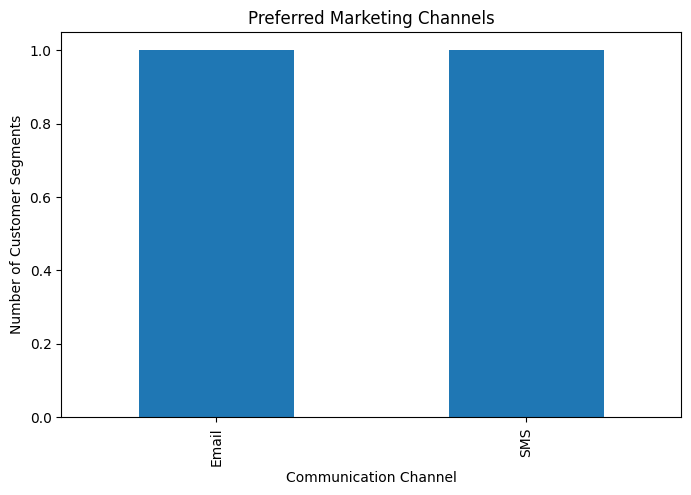

In [21]:
import matplotlib.pyplot as plt

marketing_strategy["Preferred Channel"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Preferred Marketing Channels")
plt.xlabel("Communication Channel")
plt.ylabel("Number of Customer Segments")

plt.show()

# Task 5: Product Recommendation Strategy

### Create Product Recommendation Table

In [22]:
segments = df["Business_Name"].unique()

product_recommendation = pd.DataFrame({
    "Customer Segment": segments
})

product_recommendation

,Customer Segment
0,Premium Loyal Customers
1,Budget Buyers


### : Generate Product Recommendations

In [23]:
primary = []
secondary = []
cross_sell = []
upsell = []
bundle = []

for segment in product_recommendation["Customer Segment"]:

    if "Premium" in segment:

        primary.append("Wine")
        secondary.append("Gold Products")
        cross_sell.append("Premium Meat Products")
        upsell.append("Luxury Gift Hampers")
        bundle.append("Wine + Gold Products Bundle")

    elif "Budget" in segment:

        primary.append("Sweets")
        secondary.append("Fruits")
        cross_sell.append("Fish Products")
        upsell.append("Family Value Packs")
        bundle.append("Fruits + Sweets Combo")

    elif "New" in segment:

        primary.append("Wine")
        secondary.append("Meat Products")
        cross_sell.append("Gold Products")
        upsell.append("Starter Premium Bundle")
        bundle.append("Wine + Meat Bundle")

    elif "Risk" in segment:

        primary.append("Discounted Products")
        secondary.append("Sweets")
        cross_sell.append("Fruits")
        upsell.append("Limited-Time Offers")
        bundle.append("Discount Combo Pack")

    else:

        primary.append("Popular Products")
        secondary.append("Recommended Products")
        cross_sell.append("Frequently Bought Together")
        upsell.append("Premium Upgrade")
        bundle.append("Customized Bundle")

### Add Recommendations to Table

In [24]:
product_recommendation["Primary Product"] = primary
product_recommendation["Secondary Product"] = secondary
product_recommendation["Cross-Selling Product"] = cross_sell
product_recommendation["Upselling Product"] = upsell
product_recommendation["Bundle Recommendation"] = bundle

product_recommendation

,Customer Segment,Primary Product,Secondary Product,Cross-Selling Product,Upselling Product,Bundle Recommendation
0,Premium Loyal Customers,Wine,Gold Products,Premium Meat Products,Luxury Gift Hampers,Wine + Gold Products Bundle
1,Budget Buyers,Sweets,Fruits,Fish Products,Family Value Packs,Fruits + Sweets Combo


### Product Recommendation Chart

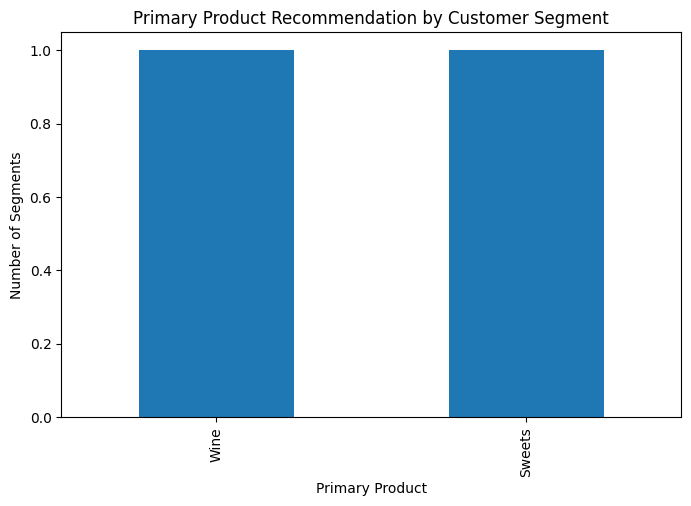

In [25]:
import matplotlib.pyplot as plt

product_recommendation["Primary Product"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Primary Product Recommendation by Customer Segment")
plt.xlabel("Primary Product")
plt.ylabel("Number of Segments")

plt.show()

# Task 6: Pricing and Discount Strategy

### Create Discount Strategy Table

In [26]:
segments = df["Business_Name"].unique()

discount_strategy = pd.DataFrame({
    "Customer Segment": segments
})

discount_strategy

,Customer Segment
0,Premium Loyal Customers
1,Budget Buyers


### Generate Pricing & Discount Strategy

In [27]:
discount_percentage = []
coupon_strategy = []
promotional_offer = []
seasonal_offer = []
premium_pricing = []

for segment in discount_strategy["Customer Segment"]:

    if "Premium" in segment:

        discount_percentage.append("5%")
        coupon_strategy.append("Exclusive VIP Coupons")
        promotional_offer.append("Luxury Gift with Purchase")
        seasonal_offer.append("Premium Holiday Collection")
        premium_pricing.append("Yes")

    elif "Budget" in segment:

        discount_percentage.append("25%")
        coupon_strategy.append("Weekly Discount Coupons")
        promotional_offer.append("Buy 2 Get 1 Free")
        seasonal_offer.append("Festival Discount Sale")
        premium_pricing.append("No")

    elif "New" in segment:

        discount_percentage.append("15%")
        coupon_strategy.append("First Purchase Coupon")
        promotional_offer.append("Welcome Bonus")
        seasonal_offer.append("New Customer Offer")
        premium_pricing.append("No")

    elif "Risk" in segment:

        discount_percentage.append("30%")
        coupon_strategy.append("Win-Back Coupon")
        promotional_offer.append("Limited-Time Discount")
        seasonal_offer.append("Reactivation Campaign")
        premium_pricing.append("No")

    else:

        discount_percentage.append("10%")
        coupon_strategy.append("General Discount Coupon")
        promotional_offer.append("Seasonal Promotion")
        seasonal_offer.append("Special Event Sale")
        premium_pricing.append("Optional")

### Create Discount Recommendation Matrix

In [28]:
discount_strategy["Discount Percentage"] = discount_percentage
discount_strategy["Coupon Strategy"] = coupon_strategy
discount_strategy["Promotional Offer"] = promotional_offer
discount_strategy["Seasonal Offer"] = seasonal_offer
discount_strategy["Premium Pricing"] = premium_pricing

discount_strategy

,Customer Segment,Discount Percentage,Coupon Strategy,Promotional Offer,Seasonal Offer,Premium Pricing
0,Premium Loyal Customers,5%,Exclusive VIP Coupons,Luxury Gift with Purchase,Premium Holiday Collection,Yes
1,Budget Buyers,25%,Weekly Discount Coupons,Buy 2 Get 1 Free,Festival Discount Sale,No


### Discount Comparison Chart

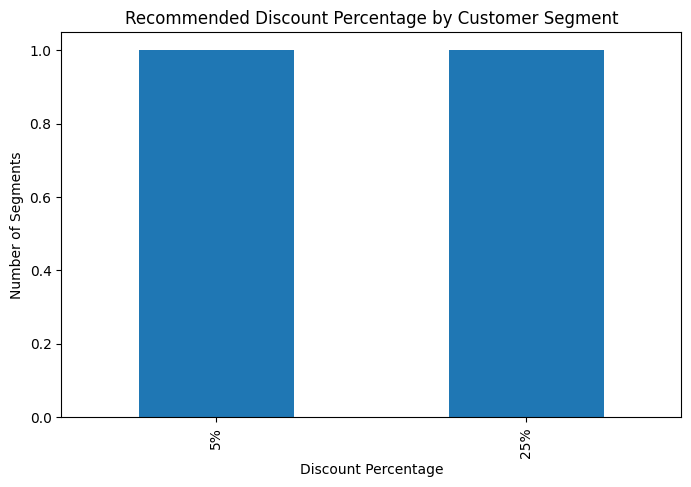

In [29]:
import matplotlib.pyplot as plt

discount_strategy["Discount Percentage"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Recommended Discount Percentage by Customer Segment")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Segments")

plt.show()

# Task 7: Customer Retention Strategy

### Create Retention Strategy Table

In [30]:
segments = df["Business_Name"].unique()

retention_strategy = pd.DataFrame({
    "Customer Segment": segments
})

retention_strategy

,Customer Segment
0,Premium Loyal Customers
1,Budget Buyers


### Generate Retention Strategy

In [31]:
loyalty_rewards = []
retention_campaign = []
follow_up = []
support_priority = []
membership_plan = []
referral_incentive = []

for segment in retention_strategy["Customer Segment"]:

    if "Premium" in segment:

        loyalty_rewards.append("VIP Reward Points")
        retention_campaign.append("Exclusive Loyalty Program")
        follow_up.append("Weekly")
        support_priority.append("High Priority")
        membership_plan.append("Gold Membership")
        referral_incentive.append("Premium Referral Bonus")

    elif "Budget" in segment:

        loyalty_rewards.append("Cashback Rewards")
        retention_campaign.append("Discount Campaign")
        follow_up.append("Bi-Weekly")
        support_priority.append("Medium Priority")
        membership_plan.append("Silver Membership")
        referral_incentive.append("Discount Coupon")

    elif "New" in segment:

        loyalty_rewards.append("Welcome Reward Points")
        retention_campaign.append("Onboarding Campaign")
        follow_up.append("Weekly")
        support_priority.append("Medium Priority")
        membership_plan.append("Starter Membership")
        referral_incentive.append("First Referral Bonus")

    elif "Risk" in segment:

        loyalty_rewards.append("Win-Back Rewards")
        retention_campaign.append("Customer Reactivation Campaign")
        follow_up.append("Every 3 Days")
        support_priority.append("Highest Priority")
        membership_plan.append("Free Membership Upgrade")
        referral_incentive.append("Double Referral Rewards")

    else:

        loyalty_rewards.append("Standard Reward Points")
        retention_campaign.append("General Engagement Campaign")
        follow_up.append("Monthly")
        support_priority.append("Normal Priority")
        membership_plan.append("Basic Membership")
        referral_incentive.append("Referral Voucher")

### Create Retention Strategy Document

In [32]:
retention_strategy["Loyalty Rewards"] = loyalty_rewards
retention_strategy["Retention Campaign"] = retention_campaign
retention_strategy["Follow-up Frequency"] = follow_up
retention_strategy["Customer Support Priority"] = support_priority
retention_strategy["Membership Plan"] = membership_plan
retention_strategy["Referral Incentive"] = referral_incentive

retention_strategy

,Customer Segment,Loyalty Rewards,Retention Campaign,Follow-up Frequency,Customer Support Priority,Membership Plan,Referral Incentive
0,Premium Loyal Customers,VIP Reward Points,Exclusive Loyalty Program,Weekly,High Priority,Gold Membership,Premium Referral Bonus
1,Budget Buyers,Cashback Rewards,Discount Campaign,Bi-Weekly,Medium Priority,Silver Membership,Discount Coupon


### Visualize Follow-up Frequency

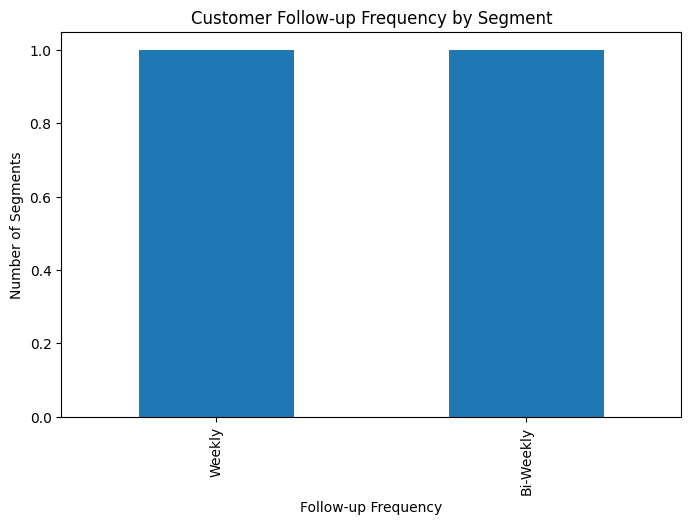

In [33]:
import matplotlib.pyplot as plt

retention_strategy["Follow-up Frequency"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Follow-up Frequency by Segment")
plt.xlabel("Follow-up Frequency")
plt.ylabel("Number of Segments")

plt.show()

# Task 8: Customer Reactivation Strategy

### Identify Inactive Customers

In [34]:
inactive_customers = df[df["Recency"] > 60]

print("Total Inactive Customers :", len(inactive_customers))

inactive_customers.head()

Total Inactive Customers : 0


,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Total_Campaign,Average Spending per Purchase,Digital_Engagement,Deal_Dependency,Preferred_Shopping_Channel,Product_Preference,Customer_Activity_Level,Cluster,Customer_Segment,Business_Name


### : Inactive Customers by Segment

In [37]:
inactive_summary = inactive_customers.groupby("Business_Name").size().reset_index(name="Inactive Customers")

inactive_summary

,Business_Name,Inactive Customers


### : Create Customer Reactivation Plan

In [38]:
reactivation_plan = pd.DataFrame({
    "Customer Segment": inactive_summary["Business_Name"]
})

reactivation_plan

,Customer Segment


### Generate Reactivation Strategy

In [39]:
win_back_offer = []
reminder_campaign = []
recommendation = []
timeline = []

for segment in reactivation_plan["Customer Segment"]:

    if "Premium" in segment:

        win_back_offer.append("Exclusive VIP Discount (10%)")
        reminder_campaign.append("Personalized Email Reminder")
        recommendation.append("Premium Wine & Gold Products")
        timeline.append("Within 7 Days")

    elif "Budget" in segment:

        win_back_offer.append("25% Discount Coupon")
        reminder_campaign.append("SMS Discount Reminder")
        recommendation.append("Bundle Offers & Family Packs")
        timeline.append("Within 10 Days")

    elif "New" in segment:

        win_back_offer.append("Welcome Back Coupon (15%)")
        reminder_campaign.append("Email + App Notification")
        recommendation.append("Popular Products")
        timeline.append("Within 5 Days")

    elif "Risk" in segment:

        win_back_offer.append("30% Win-Back Offer")
        reminder_campaign.append("SMS + Email + Phone Call")
        recommendation.append("Personalized Product Recommendations")
        timeline.append("Immediately")

    else:

        win_back_offer.append("Seasonal Discount")
        reminder_campaign.append("Email Campaign")
        recommendation.append("Trending Products")
        timeline.append("Within 2 Weeks")

### Create Final Reactivation Table

In [40]:
reactivation_plan["Win-back Offer"] = win_back_offer
reactivation_plan["Reminder Campaign"] = reminder_campaign
reactivation_plan["Personalized Recommendation"] = recommendation
reactivation_plan["Reactivation Timeline"] = timeline

reactivation_plan

,Customer Segment,Win-back Offer,Reminder Campaign,Personalized Recommendation,Reactivation Timeline


# Task 9: Campaign Action Plan

### Create Campaign Action Plan

In [42]:
segments = df["Business_Name"].unique()

campaign_plan = pd.DataFrame({
    "Target Segment": segments
})

campaign_plan

,Target Segment
0,Premium Loyal Customers
1,Budget Buyers


### Generate Campaign Strategy

In [43]:
campaign_name = []
campaign_objective = []
marketing_channel = []
budget_priority = []
expected_outcome = []
kpi = []

for segment in campaign_plan["Target Segment"]:

    if "Premium" in segment:

        campaign_name.append("VIP Rewards")
        campaign_objective.append("Increase Customer Loyalty")
        marketing_channel.append("Email")
        budget_priority.append("High")
        expected_outcome.append("Higher Repeat Purchases")
        kpi.append("Repeat Purchase Rate")

    elif "Budget" in segment:

        campaign_name.append("Discount Week")
        campaign_objective.append("Increase Sales")
        marketing_channel.append("SMS")
        budget_priority.append("Medium")
        expected_outcome.append("Higher Conversion Rate")
        kpi.append("Conversion Rate")

    elif "New" in segment:

        campaign_name.append("Welcome Campaign")
        campaign_objective.append("Increase Customer Engagement")
        marketing_channel.append("Email + Mobile App")
        budget_priority.append("Medium")
        expected_outcome.append("More First-Time Purchases")
        kpi.append("Customer Activation Rate")

    elif "Risk" in segment:

        campaign_name.append("Win-Back Campaign")
        campaign_objective.append("Reduce Customer Churn")
        marketing_channel.append("SMS + Email")
        budget_priority.append("High")
        expected_outcome.append("Recovered Inactive Customers")
        kpi.append("Customer Retention Rate")

    else:

        campaign_name.append("General Promotion")
        campaign_objective.append("Increase Customer Activity")
        marketing_channel.append("Email")
        budget_priority.append("Low")
        expected_outcome.append("Improved Customer Engagement")
        kpi.append("Engagement Rate")

### Create Campaign Action Plan Table

In [44]:
campaign_plan["Campaign"] = campaign_name
campaign_plan["Campaign Objective"] = campaign_objective
campaign_plan["Marketing Channel"] = marketing_channel
campaign_plan["Budget Priority"] = budget_priority
campaign_plan["Expected Outcome"] = expected_outcome
campaign_plan["Success KPI"] = kpi

campaign_plan

,Target Segment,Campaign,Campaign Objective,Marketing Channel,Budget Priority,Expected Outcome,Success KPI
0,Premium Loyal Customers,VIP Rewards,Increase Customer Loyalty,Email,High,Higher Repeat Purchases,Repeat Purchase Rate
1,Budget Buyers,Discount Week,Increase Sales,SMS,Medium,Higher Conversion Rate,Conversion Rate


### Campaign Budget Chart

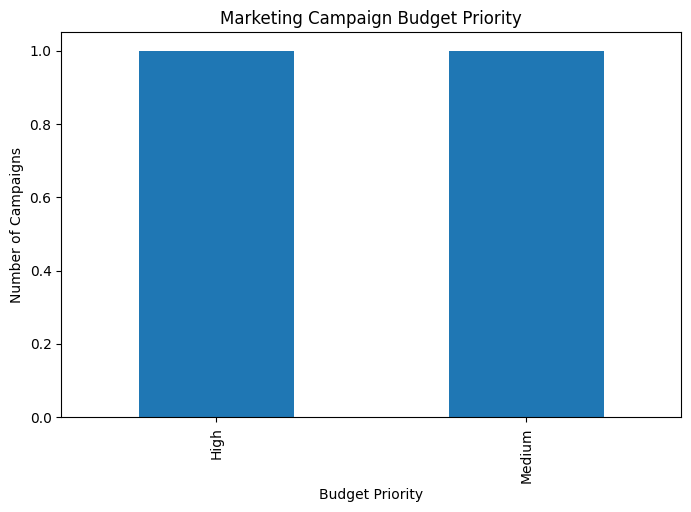

In [45]:
import matplotlib.pyplot as plt

campaign_plan["Budget Priority"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Marketing Campaign Budget Priority")
plt.xlabel("Budget Priority")
plt.ylabel("Number of Campaigns")

plt.show()

# Task 10: Marketing Strategy Matrix

### Merge All Strategy Tables

In [46]:
marketing_matrix = marketing_strategy.merge(

    product_recommendation,

    on="Customer Segment"

).merge(

    discount_strategy,

    on="Customer Segment"

).merge(

    retention_strategy,

    on="Customer Segment"

).merge(

    reactivation_plan,

    on="Customer Segment"

)

marketing_matrix.head()

,Customer Segment,Marketing Message,Tone of Communication,Personalized Offer,Preferred Channel,Best Campaign Timing,Campaign Frequency,Primary Product,Secondary Product,Cross-Selling Product,...,Loyalty Rewards,Retention Campaign,Follow-up Frequency,Customer Support Priority,Membership Plan,Referral Incentive,Win-back Offer,Reminder Campaign,Personalized Recommendation,Reactivation Timeline


### Select Required Columns

In [47]:
final_strategy_matrix = marketing_matrix[[

    "Customer Segment",

    "Marketing Message",

    "Preferred Channel",

    "Primary Product",

    "Discount Percentage",

    "Loyalty Rewards",

    "Cross-Selling Product",

    "Upselling Product",

    "Campaign Frequency",

    "Win-back Offer"

]]

final_strategy_matrix

,Customer Segment,Marketing Message,Preferred Channel,Primary Product,Discount Percentage,Loyalty Rewards,Cross-Selling Product,Upselling Product,Campaign Frequency,Win-back Offer


### Rename Columns

In [48]:
final_strategy_matrix.columns = [

    "Segment Name",

    "Marketing Message",

    "Communication Channel",

    "Product Recommendation",

    "Discount Strategy",

    "Loyalty Strategy",

    "Cross-selling",

    "Upselling",

    "Campaign Frequency",

    "Reactivation Strategy"

]

final_strategy_matrix

,Segment Name,Marketing Message,Communication Channel,Product Recommendation,Discount Strategy,Loyalty Strategy,Cross-selling,Upselling,Campaign Frequency,Reactivation Strategy


### Display Complete Marketing Strategy Matrix

In [49]:
print("="*120)

print("FINAL MARKETING STRATEGY MATRIX")

print("="*120)

final_strategy_matrix

FINAL MARKETING STRATEGY MATRIX


,Segment Name,Marketing Message,Communication Channel,Product Recommendation,Discount Strategy,Loyalty Strategy,Cross-selling,Upselling,Campaign Frequency,Reactivation Strategy


# Task 11: Business Dashboard

### Customers per Segment

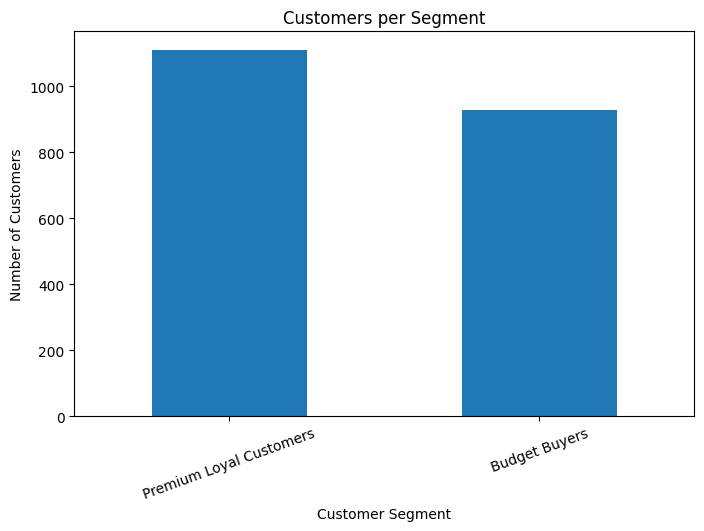

In [51]:
customer_count = df["Business_Name"].value_counts()

plt.figure(figsize=(8,5))

customer_count.plot(kind="bar")

plt.title("Customers per Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### Revenue Contribution by Segment

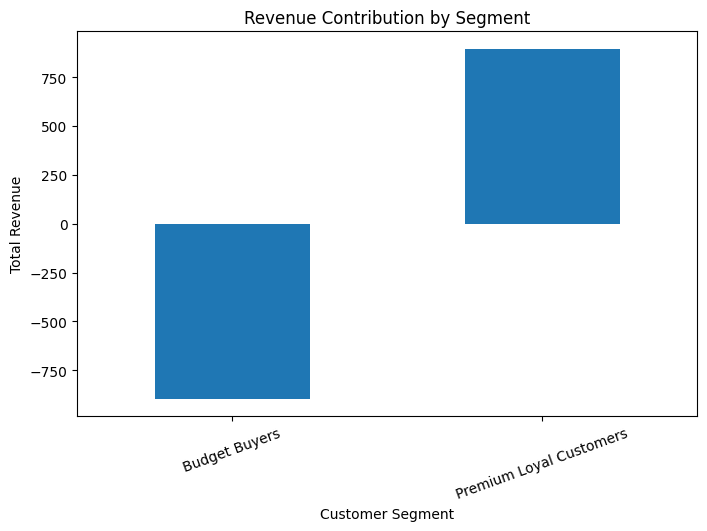

In [52]:
revenue = df.groupby("Business_Name")["Total_spending"].sum()

plt.figure(figsize=(8,5))

revenue.plot(kind="bar")

plt.title("Revenue Contribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=20)

plt.show()

### Campaign Budget Priority

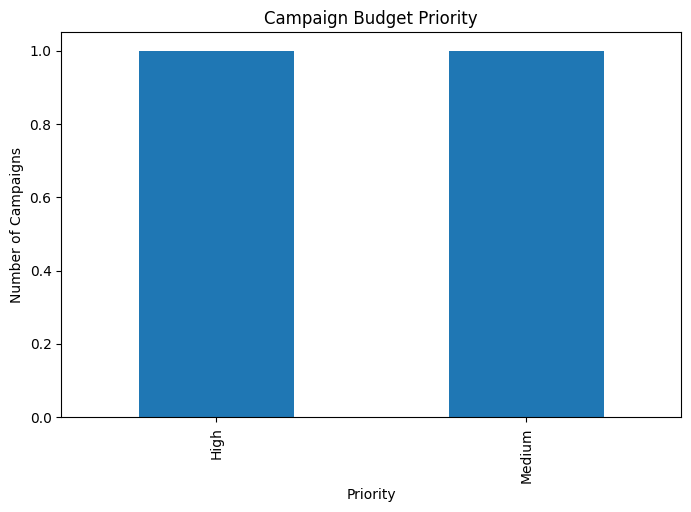

In [53]:
campaign_plan["Budget Priority"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Campaign Budget Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Campaigns")

plt.show()

### Churn Risk by Segment

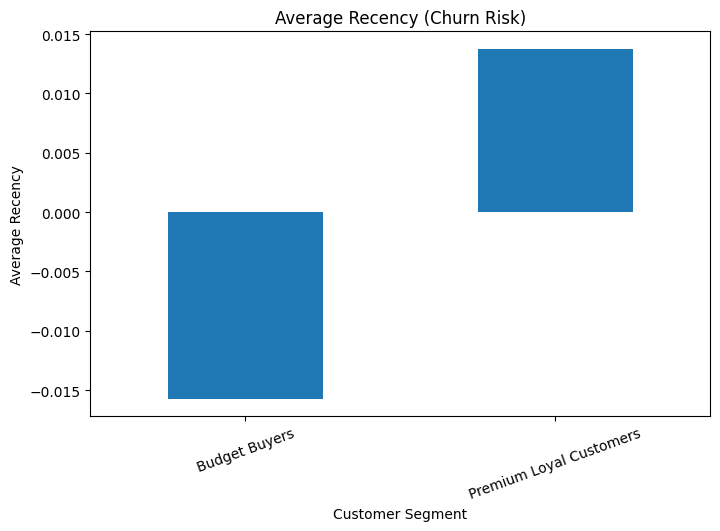

In [54]:
risk = df.groupby("Business_Name")["Recency"].mean()

plt.figure(figsize=(8,5))

risk.plot(kind="bar")

plt.title("Average Recency (Churn Risk)")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recency")

plt.xticks(rotation=20)

plt.show()

### Recommended Marketing Channels

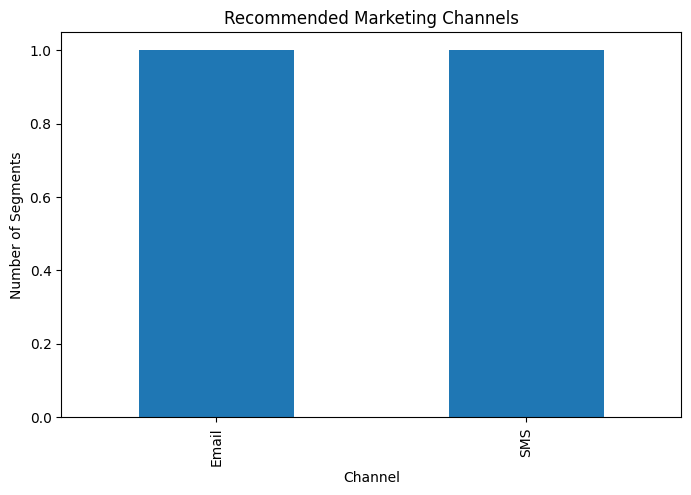

In [55]:
marketing_strategy["Preferred Channel"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Recommended Marketing Channels")
plt.xlabel("Channel")
plt.ylabel("Number of Segments")

plt.show()

### Product Preferences

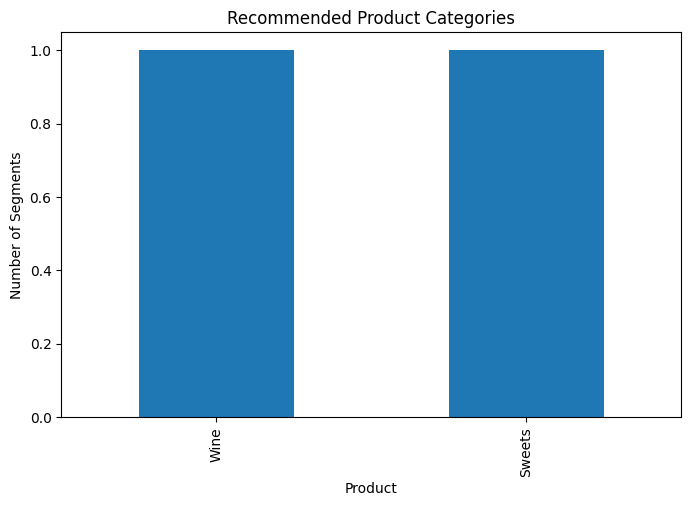

In [56]:
product_recommendation["Primary Product"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Recommended Product Categories")
plt.xlabel("Product")
plt.ylabel("Number of Segments")

plt.show()

### Dashboard Summary

In [57]:
print("="*70)
print("BUSINESS INSIGHTS DASHBOARD")
print("="*70)

print("\nTotal Customer Segments :", df["Business_Name"].nunique())

print("Total Customers :", len(df))

print("Total Revenue :", round(df["Total_spending"].sum(),2))

print("Average Customer Income :", round(df["Income"].mean(),2))

print("Average Spending :", round(df["Total_spending"].mean(),2))

BUSINESS INSIGHTS DASHBOARD

Total Customer Segments : 2
Total Customers : 2038
Total Revenue : -1.9
Average Customer Income : 0.0
Average Spending : -0.0


# Task 12: Management Summary Report